In [ ]:
import pandas as pd
import numpy as np
import os
import datetime as dt
import missingno as msno
import seaborn as sns
import matplotlib as plt
import json


### Data frame creator

In [ ]:
df_smog = pd.read_csv('../data/smog_raw.csv', encoding='utf-8-sig')
df_smog2 = pd.read_csv('../data/smog_raw2.csv', encoding='utf-8-sig')


### Pokazanie czy działa formatowanie - brak błędów polskich znaków - niestety nie potrafie naprawić

In [ ]:
print(df_smog['NAME'].head())


0    SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...
1                    SZKO?A PODSTAWOWA WE WRZ?SOWICACH
2                        ZESP?? SZK?? NR 1 W PSZCZYNIE
3    ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...
4    SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...
Name: NAME, dtype: str


### Nazwy nagłówków

In [ ]:
print(df_smog.columns)


Index(['NAME', 'STREET', 'POST_CODE', 'CITY', 'LONGITUDE', 'LATITUDE',
       'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG',
       'PM25_AVG', 'TIMESTAMP'],
      dtype='str')


### Opis danych

In [ ]:
df_smog.isna().info()


<class 'pandas.DataFrame'>
RangeIndex: 1630 entries, 0 to 1629
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   NAME             1630 non-null   bool 
 1   STREET           1630 non-null   bool 
 2   POST_CODE        1630 non-null   bool 
 3   CITY             1630 non-null   bool 
 4   LONGITUDE        1630 non-null   bool 
 5   LATITUDE         1630 non-null   bool 
 6   HUMIDITY_AVG     1630 non-null   bool 
 7   PRESSURE_AVG     1630 non-null   bool 
 8   TEMPERATURE_AVG  1630 non-null   bool 
 9   PM10_AVG         1630 non-null   bool 
 10  PM25_AVG         1630 non-null   bool 
 11  TIMESTAMP        1630 non-null   bool 
dtypes: bool(12)
memory usage: 19.2 KB


### Opis typu danych w kolumnach

In [ ]:
print(df_smog.dtypes)


NAME                   str
STREET                 str
POST_CODE              str
CITY                   str
LONGITUDE          float64
LATITUDE           float64
HUMIDITY_AVG       float64
PRESSURE_AVG       float64
TEMPERATURE_AVG    float64
PM10_AVG           float64
PM25_AVG           float64
TIMESTAMP              str
dtype: object


### Zmiana typu danych w kolumnie 'Date' na datetime

In [ ]:
df_smog['TIMESTAMP_DATETIME'] = pd.to_datetime(df_smog['TIMESTAMP'], errors='coerce')


### Wyciągam datę

In [ ]:
df_smog['TYLKO_DATA'] = df_smog['TIMESTAMP_DATETIME'].dt.date


### Wyciągamy sam czas (Format: GG:MM:SS)

In [ ]:
df_smog['TYLKO_CZAS'] = df_smog['TIMESTAMP_DATETIME'].dt.time


### Usuwamy kolumnę pomocniczą

In [ ]:
df_smog = df_smog.drop(columns=['TIMESTAMP_DATETIME'])


### Podgląd danych po zmianie formatowania daty i czasu

In [ ]:
print(df_smog['TYLKO_CZAS'].head())


0    00:00:00
1    00:00:00
2    00:00:00
3    00:00:00
4    00:00:00
Name: TYLKO_CZAS, dtype: object


### Podgląd nazw nagłówków w tabeli

In [ ]:
df_smog.head(2)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63-522,KRASZEWICE,18.22403,51.51563,99.900000,1011.766667,19.166667,8.333333,4.606667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1,SZKO?A PODSTAWOWA WE WRZ?SOWICACH,UL. SZKOLNA,32-040,WRZ?SOWICE,19.94282,49.96103,58.408333,978.891667,27.316667,11.525000,10.300000,2026-07-01 00:00:00.0,2026-07-01,00:00:00


### Podstawowe statystyki opisowe [według typów danych]

In [ ]:
df_smog.describe()


,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG
count,1630.000000,1630.000000,1628.000000,1628.000000,1628.000000,1630.000000,1630.000000
mean,18.904510,51.309319,73.316980,994.446771,24.142856,12.088895,9.877521
std,4.838756,1.775687,13.402061,14.784627,3.302562,9.005344,7.374002
min,-157.529698,1.858685,27.500000,936.900000,-40.000000,0.000000,0.000000
25%,17.009585,50.139394,63.527083,984.725000,21.862311,4.758750,4.025000
50%,19.037460,51.135540,72.412500,994.941667,24.804167,11.212500,9.595833
75%,20.690997,52.389384,81.891667,1005.285417,26.375000,16.515000,13.408333
max,23.873936,54.661981,100.000000,1100.000000,31.800000,85.800000,81.680000


### Sortowanie po kodzie pocztowym [TEMPERATURE_AVG to średnia temperatury, kod pocztowy to POST_CODE ;)]

In [ ]:
df_smog.sort_values(['TEMPERATURE_AVG']).head(20)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
592,ZESP?? SZK?? NR4-SZKO?A PODSTAWOWA W SOPOTNI W...,NaN,34-340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.000000,30.616667,26.558333,2026-07-01 00:00:00.0,2026-07-01,00:00:00
52,SZKO?A PODSTAWOWA IM. TADEUSZA MAZOWIECKIEGO W...,SZKOLNA,55-040,TYNIEC MA?Y,16.909195,51.021600,67.800000,1019.160000,2.500000,39.960000,21.930000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
71,SZKO?A PODSTAWOWA IM. TADEUSZA KO?CIUSZKI W MU...,3-GO MAJA,37-514,MUNINA,22.725977,49.997936,56.500000,996.300000,6.800000,68.400000,42.610000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
80,SZKO?A PODSTAWOWA IM. MARII SK?ODOWSKIEJ-CURIE...,KAW?CZYN,62-704,KAW?CZYN,18.531260,51.908730,91.880000,1014.650000,8.930000,28.280000,16.420000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
86,ZESP?? EDUKACYJNY W KOLSKU,PIASTOWSKA,67-415,KOLSKO,15.961961,51.960693,88.340000,1020.570000,9.940000,37.830000,22.350000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1303,SZKO?A PODSTAWOWA IM. OJCA ?WI?TEGO JANA PAW?A...,UL. WITOSA,33-131,??G TARNOWSKI,20.928012,50.092030,53.933333,996.766667,10.000000,14.783333,15.466667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1387,SZKO?A PODSTAWOWA EKOLA WROC?AW,UL. ZIELI?SKIEGO,53-534,WROC?AW,17.020853,51.097829,64.050000,985.083333,10.000000,16.058333,15.316667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
96,SZKO?A PODSTAWOWA NR 1 IM. STRAJKU DZIECI KO?M...,GLINKI,63-720,KO?MIN WIELKOPOLSKI,17.456510,51.825660,88.500000,1007.100000,13.300000,19.500000,11.760000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1287,SZKO?A PODSTAWOWA IM. JANA PAW?A II W BA?YNACH,NaN,11-130,BA?YNY,20.042061,54.132021,81.375000,1015.358333,15.925000,2.641667,1.891667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,SZKOLNA,63-421,JANK?W PRZYGODZKI,17.788907,51.596172,99.900000,992.400000,16.400000,21.300000,11.150000,2026-07-01 00:00:00.0,2026-07-01,00:00:00


### Mapa braków

<Axes: >

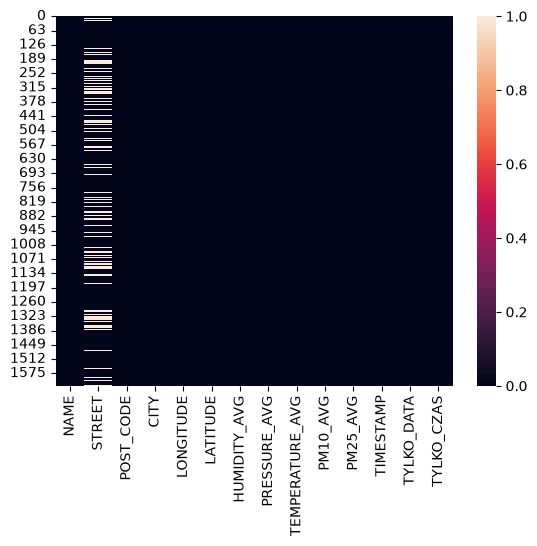

In [ ]:
sns.heatmap(df_smog.isna())


### Set variables

In [ ]:
area_dict = {
    "00-09": "mazowieckie",
    "10-19": "warminsko-mazurskie",
    "20-29": "lubelskie",
    "30-39": "malopolskie",
    "50-59": "dolnoslaskie",
    "60-69": "wielkopolskie",
    "70-79": "zachodniopomorskie",
    "80-89": "pomorskie",
    "90-99": "lodzkie"
}
smog_columns = ['LONGITUDE', 'LATITUDE', 'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG', 'PM25_AVG']


### Insert area column and get postal code area number

In [ ]:
df_smog.insert(2, 'AREA', df_smog['POST_CODE'].astype(str).str[:2].astype(int))


### Data frame shape

In [ ]:
df_smog.shape


(1630, 15)

In [ ]:
df_smog2.shape


(1621, 12)

### Data frame first look

In [ ]:
df_smog


,NAME,STREET,AREA,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63,63-522,KRASZEWICE,18.224030,51.515630,99.900000,1011.766667,19.166667,8.333333,4.606667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1,SZKO?A PODSTAWOWA WE WRZ?SOWICACH,UL. SZKOLNA,32,32-040,WRZ?SOWICE,19.942820,49.961030,58.408333,978.891667,27.316667,11.525000,10.300000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
2,ZESP?? SZK?? NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43,43-200,PSZCZYNA,18.945706,49.965883,99.900000,999.900000,25.933333,27.733333,16.193333,2026-07-01 00:00:00.0,2026-07-01,00:00:00
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,SZKOLNA,63,63-421,JANK?W PRZYGODZKI,17.788907,51.596172,99.900000,992.400000,16.400000,21.300000,11.150000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
4,SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...,UL. M?CZENNIK?W O?WI?CIMSKICH,43,43-229,?WIKLICE,18.989839,49.971937,92.666667,986.333333,26.366667,27.633333,14.266667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,SZKO?A PODSTAWOWA IM.BOHATER?W WRZE?NIA 1939R....,KONOPNICKIEJ,34,34-240,JORDAN?W,19.834938,49.653449,81.545455,960.445455,23.745455,20.445455,20.190909,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1626,PRZEDSZKOLE NR 10 W PIASECZNIE,NADARZY?SKA,5,05-500,PIASECZNO,21.017680,52.072370,51.491667,1006.391667,26.358333,3.325000,3.050000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1627,SZKO?A PODSTAWOWA IM. JANA PAW?A II W WILCZKOWIE,UL. MIKO?AJA KOPERNIKA,55,55-020,WILCZK?W,16.989396,50.966512,71.483333,998.225000,25.333333,9.641667,9.375000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1628,PRZEDSZKOLE SAMORZ?DOWE W GOLI,NaN,63,63-800,GOLA,16.944640,51.870920,82.033333,1002.358333,22.691667,4.925000,4.925000,2026-07-01 00:00:00.0,2026-07-01,00:00:00


### Format float values with precission to 1

In [ ]:
for x in smog_columns:
    df_smog[f"{x}"] = df_smog[f"{x}"].round(1)
    df_smog2[f"{x}"] = df_smog2[f"{x}"].round(1)


### Strip '-' from post code

In [ ]:
for x in df_smog['POST_CODE']:
    df_smog['POST_CODE'] = df_smog['POST_CODE'].str.replace("-", "")
    df_smog2['POST_CODE'] = df_smog2['POST_CODE'].str.replace("-", "")


In [ ]:
df_smog.head(5)


,NAME,STREET,AREA,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63,63522,KRASZEWICE,18.2,51.5,99.9,1011.8,19.2,8.3,4.6,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1,SZKO?A PODSTAWOWA WE WRZ?SOWICACH,UL. SZKOLNA,32,32040,WRZ?SOWICE,19.9,50.0,58.4,978.9,27.3,11.5,10.3,2026-07-01 00:00:00.0,2026-07-01,00:00:00
2,ZESP?? SZK?? NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43,43200,PSZCZYNA,18.9,50.0,99.9,999.9,25.9,27.7,16.2,2026-07-01 00:00:00.0,2026-07-01,00:00:00
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,SZKOLNA,63,63421,JANK?W PRZYGODZKI,17.8,51.6,99.9,992.4,16.4,21.3,11.2,2026-07-01 00:00:00.0,2026-07-01,00:00:00
4,SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...,UL. M?CZENNIK?W O?WI?CIMSKICH,43,43229,?WIKLICE,19.0,50.0,92.7,986.3,26.4,27.6,14.3,2026-07-01 00:00:00.0,2026-07-01,00:00:00


In [ ]:
df_smog2.tail(5)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP
1616,PRZEDSZKOLE NR 10 W PIASECZNIE,NADARZY?SKA,05500,PIASECZNO,21.0,52.1,74.6,1004.4,20.2,2.3,2.1,2026-07-02 11:00:00.0
1617,SZKO?A PODSTAWOWA IM. JANA PAW?A II W WILCZKOWIE,UL. MIKO?AJA KOPERNIKA,55020,WILCZK?W,17.0,51.0,54.0,1000.8,24.9,3.5,3.3,2026-07-02 11:00:00.0
1618,PRZEDSZKOLE SAMORZ?DOWE W GOLI,NaN,63800,GOLA,16.9,51.9,64.6,1003.8,23.0,2.0,2.0,2026-07-02 11:00:00.0
1619,SPO?ECZNA SZKO?A PODSTAWOWA W GZACH,NaN,06126,GZY,20.9,52.7,64.0,1003.0,22.5,2.6,2.1,2026-07-02 11:00:00.0
1620,ZESP?? SZKOLNO-PRZEDSZKOLNY W KSI??U WIELKIM,UL. MIKO?AJA REJA,32210,KSI?? WIELKI,20.1,50.4,84.6,987.2,16.4,19.4,15.0,2026-07-02 11:00:00.0


### Shape after first format

In [ ]:
df_smog.shape


(1630, 15)

In [ ]:
df_smog2.shape


(1621, 12)

### Data frame look

In [ ]:
df_smog.head(5)


,NAME,STREET,AREA,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63,63522,KRASZEWICE,18.2,51.5,99.9,1011.8,19.2,8.3,4.6,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1,SZKO?A PODSTAWOWA WE WRZ?SOWICACH,UL. SZKOLNA,32,32040,WRZ?SOWICE,19.9,50.0,58.4,978.9,27.3,11.5,10.3,2026-07-01 00:00:00.0,2026-07-01,00:00:00
2,ZESP?? SZK?? NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43,43200,PSZCZYNA,18.9,50.0,99.9,999.9,25.9,27.7,16.2,2026-07-01 00:00:00.0,2026-07-01,00:00:00
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,SZKOLNA,63,63421,JANK?W PRZYGODZKI,17.8,51.6,99.9,992.4,16.4,21.3,11.2,2026-07-01 00:00:00.0,2026-07-01,00:00:00
4,SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...,UL. M?CZENNIK?W O?WI?CIMSKICH,43,43229,?WIKLICE,19.0,50.0,92.7,986.3,26.4,27.6,14.3,2026-07-01 00:00:00.0,2026-07-01,00:00:00


In [ ]:
df_smog2.tail(5)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP
1616,PRZEDSZKOLE NR 10 W PIASECZNIE,NADARZY?SKA,05500,PIASECZNO,21.0,52.1,74.6,1004.4,20.2,2.3,2.1,2026-07-02 11:00:00.0
1617,SZKO?A PODSTAWOWA IM. JANA PAW?A II W WILCZKOWIE,UL. MIKO?AJA KOPERNIKA,55020,WILCZK?W,17.0,51.0,54.0,1000.8,24.9,3.5,3.3,2026-07-02 11:00:00.0
1618,PRZEDSZKOLE SAMORZ?DOWE W GOLI,NaN,63800,GOLA,16.9,51.9,64.6,1003.8,23.0,2.0,2.0,2026-07-02 11:00:00.0
1619,SPO?ECZNA SZKO?A PODSTAWOWA W GZACH,NaN,06126,GZY,20.9,52.7,64.0,1003.0,22.5,2.6,2.1,2026-07-02 11:00:00.0
1620,ZESP?? SZKOLNO-PRZEDSZKOLNY W KSI??U WIELKIM,UL. MIKO?AJA REJA,32210,KSI?? WIELKI,20.1,50.4,84.6,987.2,16.4,19.4,15.0,2026-07-02 11:00:00.0


### -[] Set missing values to 0 in smog_columns 

In [ ]:
for x in smog_columns:
    if df_smog[f"{x}"].any() == 0.0:
        print(df_smog[f"{x}"])
        #print(df_smog2[f"{x}"])
        #df_smog[f"{x}"] = df_smog2[f"{x}"]
    #print(df_smog[f"{x}"].isna().sum())


KeyboardInterrupt: 

### Data frame look

In [ ]:
df_smog


### Check, if every area is in place (longitude and latitude are in Polish area)

In [ ]:
# Define a function and area latitude and longitude min and max values

def check_areas(df):
    area_values = {
        "Latitude.North < 54.835563": df_smog['LATITUDE'] < 54.8,
        "Latitude.South > 49.002063": df_smog['LATITUDE'] > 49.0,
        "Longitude.East < 24.145562": df_smog['LONGITUDE'] < 24.2,
        "Longitude.West > 14.124562": df_smog['LONGITUDE'] > 14.0
        }
    return area_values

# Define an object table with the area checker

areas = check_areas(df_smog2)

# Print if there are any differences in the areas

for rule, result in areas.items():
    print(f"{rule}: {not result.all()}")


### Check, how many of areas have wrong latitudes\longitudes

In [ ]:
# Check, how many differences are in areas

differences = {rule: ~result for rule, result in areas.items()}
summary = {rule: result.sum() for rule, result in differences.items()}

# Print the number of differences

for rule, count in summary.items():
    print(f"{rule}: {count} differences")


NameError: name 'areas' is not defined

### Save dataframe to csv file **Always put as a last cell !**

In [ ]:
ts = dt.datetime.now().strftime("%Y%m%d_%H-%M")
#df_smog.to_csv(f"../tests/smog_raw{ts}.csv", index=False)
#df_smog2.to_csv(f"../tests/smog2_raw{ts}.csv", index=False)
